In [77]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score,cross_val_predict
from sklearn import svm
from sklearn.utils import shuffle
import matplotlib.pyplot as plt
from feature.selector import Selective, SelectionMethod
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
import shap
from itertools import cycle
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier

In [138]:
def numeric_columns(df):
    numeric_cols = []
    for col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]):
            numeric_cols.append(col)
    return numeric_cols
# Load dataset
df = pd.read_csv("TARA_mhws_3.csv")

# Use function to extract numeric columns
numeric_cols = numeric_columns(df)

# Create a copy of the DataFrame
df_numeric = df[numeric_cols].copy()

# Now you can safely modify df_numeric
df_numeric['mhw_category'] = df['mhw_category']

replace_category = {
    'none': 0,
    'Moderate': 1,
    'Strong': 2,
    'Severe': 3
}

df_numeric['mhw_category'] = df['mhw_category'].replace(replace_category)

print(df_numeric['mhw_category'].value_counts())

# Shuffle the DataFrame
shuffled_df_numeric = shuffle(df_numeric, random_state=42)

dropped = shuffled_df_numeric.drop(shuffled_df_numeric[shuffled_df_numeric['mhw_category'] == 0].index)

print(dropped['mhw_category'].value_counts())

# Shuffle the DataFrame
dropped = shuffle(dropped, random_state=42)

# Separate features (X) and labels (y) after shuffling
X = dropped.drop(['mhw_category'], axis=1)
y = dropped['mhw_category']
X.shape, y.shape

mhw_category
0    3245
1     605
2     185
3      31
Name: count, dtype: int64
mhw_category
1    605
2    185
3     31
Name: count, dtype: int64


C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_22988\2648255819.py:26: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_numeric['mhw_category'] = df['mhw_category'].replace(replace_category)


((821, 81), (821,))

In [163]:
dropped.to_csv('example_values.csv', index = False)

In [139]:
nan = np.nan
imputer = KNNImputer(n_neighbors = 4, weights = 'distance')
imputed = imputer.fit_transform(dropped)
imputed_df_dif = pd.DataFrame(imputed, columns = dropped.columns)
imputed_df_dif.shape
# Shuffle the DataFrame
shuffled_imp_dif = shuffle(imputed_df_dif, random_state=42)
shuffled_imp_dif = shuffled_imp_dif.rename({'sea surface temp': 'SST', 'sea surface chlorophyll a': 'SSCa', 'sea surface temp grad': 'SSTG'}, axis = 1)

# Separate features (X) and labels (y) after shuffling
X_imp_dif = shuffled_imp_dif.drop(['mhw_category', 'mhw_count'], axis=1)
y_imp_dif = shuffled_imp_dif['mhw_category']
print(X_imp_dif.shape)

(821, 80)


(656, 80) (656,) (165, 80) (165,)
cross validation scores: [0.94545455 0.92682927 0.93292683 0.89634146 0.9695122 ]
0.9342 accuracy with a standard deviation of 0.0239
Accuracy: 91.52%
              precision    recall  f1-score   support

         1.0       0.90      1.00      0.95       122
         2.0       1.00      0.62      0.77        37
         3.0       1.00      1.00      1.00         6

    accuracy                           0.92       165
   macro avg       0.97      0.87      0.90       165
weighted avg       0.92      0.92      0.91       165



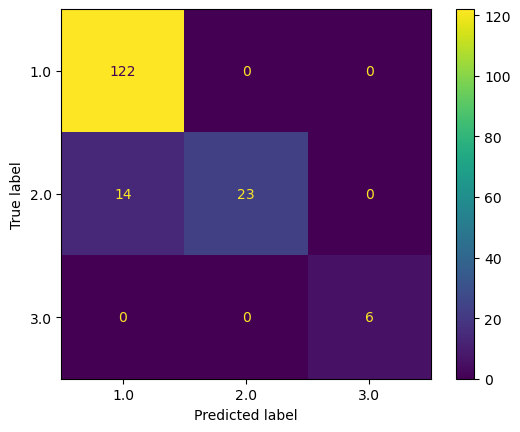

In [140]:
X_train_dif, X_test, y_train_dif, y_test = train_test_split(
    X_imp_dif, y_imp_dif, stratify = y_imp_dif, test_size=0.2, random_state=42)

print(X_train_dif.shape, y_train_dif.shape,
X_test.shape, y_test.shape)

KNN_dif = KNeighborsClassifier()
clf = Pipeline(
    steps=[("scaler", StandardScaler()), ("knn", KNN_dif)]
)
clf.fit(X_train_dif, y_train_dif)

cross_val_scores = cross_val_score(clf, X_imp_dif, y_imp_dif, cv=5)
print('cross validation scores:', cross_val_scores)
print("%0.4f accuracy with a standard deviation of %0.4f" % (cross_val_scores.mean(), cross_val_scores.std()))

y_pred = clf.predict(X_test)
prob_pred = clf.predict_proba(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

disp_3 = ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test)

print(classification_report(y_test, y_pred))

In [57]:
param_grid = [
     {'n_neighbors': [2, 3, 4, 5, 6, 7, 8, 9, 10],
      'weights': ['distance', 'uniform']
     }
]

grid = GridSearchCV(KNN_dif, param_grid, cv = 5, scoring = 'accuracy', verbose = 1)
model_grid = grid.fit(X_train_dif, y_train_dif)
print('the best score was', str(model_grid.best_score_))
print('the best parameters were', str(model_grid.best_params_))
pd.DataFrame(model_grid.cv_results_)

Fitting 5 folds for each of 18 candidates, totalling 90 fits
the best score was 0.94971084894749
the best parameters were {'n_neighbors': 2, 'weights': 'distance'}


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_neighbors,param_weights,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.006562,0.001890,0.025952,0.003853,2,distance,"{'n_neighbors': 2, 'weights': 'distance'}",0.939394,0.946565,0.931298,0.977099,0.954198,0.949711,0.015657,1
1,0.004818,0.001992,0.027076,0.003950,2,uniform,"{'n_neighbors': 2, 'weights': 'uniform'}",0.931818,0.923664,0.938931,0.954198,0.961832,0.942089,0.014081,7
2,0.004439,0.003242,0.016908,0.004677,3,distance,"{'n_neighbors': 3, 'weights': 'distance'}",0.954545,0.931298,0.908397,0.969466,0.954198,0.943581,0.021409,5
3,0.003984,0.001437,0.023882,0.006363,3,uniform,"{'n_neighbors': 3, 'weights': 'uniform'}",0.916667,0.916031,0.893130,0.931298,0.938931,0.919211,0.015696,12
4,0.004018,0.002224,0.022757,0.003810,4,distance,"{'n_neighbors': 4, 'weights': 'distance'}",0.954545,0.931298,0.908397,0.969466,0.954198,0.943581,0.021409,5
5,0.003205,0.002666,0.028636,0.005170,4,uniform,"{'n_neighbors': 4, 'weights': 'uniform'}",0.916667,0.916031,0.900763,0.923664,0.954198,0.922265,0.017631,11
6,0.010851,0.005306,0.015724,0.004827,5,distance,"{'n_neighbors': 5, 'weights': 'distance'}",0.954545,0.946565,0.908397,0.961832,0.954198,0.945108,0.018980,4
7,0.002134,0.001943,0.024428,0.007021,5,uniform,"{'n_neighbors': 5, 'weights': 'uniform'}",0.893939,0.923664,0.900763,0.923664,0.946565,0.917719,0.018739,13
8,0.003201,0.002227,0.019736,0.004744,6,distance,"{'n_neighbors': 6, 'weights': 'distance'}",0.946970,0.938931,0.908397,0.961832,0.954198,0.942066,0.018468,8
9,0.002935,0.002099,0.024060,0.004881,6,uniform,"{'n_neighbors': 6, 'weights': 'uniform'}",0.909091,0.916031,0.900763,0.916031,0.946565,0.917696,0.015490,14


(656, 80) (656,) (165, 80) (165,)
cross validation scores: [0.96969697 0.97560976 0.96341463 0.93902439 0.9695122 ]
0.9635 accuracy with a standard deviation of 0.0128
Accuracy: 96.36%
              precision    recall  f1-score   support

         1.0       0.95      1.00      0.98       122
         2.0       1.00      0.84      0.91        37
         3.0       1.00      1.00      1.00         6

    accuracy                           0.96       165
   macro avg       0.98      0.95      0.96       165
weighted avg       0.97      0.96      0.96       165



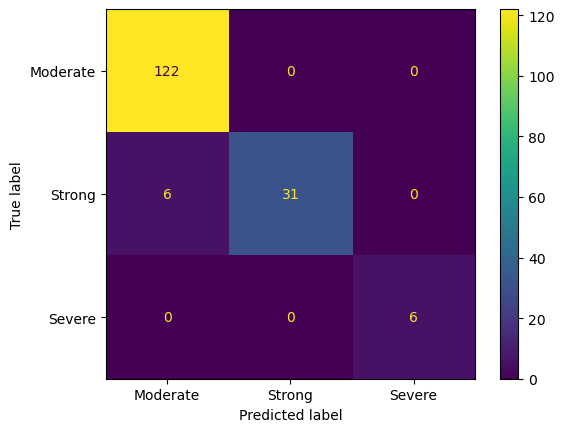

In [141]:
X_train_dif, X_test, y_train_dif, y_test = train_test_split(
    X_imp_dif, y_imp_dif, stratify = y_imp_dif, test_size=0.2, random_state=42)

print(X_train_dif.shape, y_train_dif.shape,
X_test.shape, y_test.shape)

KNN_dif = KNeighborsClassifier(n_neighbors = 2, weights = 'distance')
clf = Pipeline(
    steps=[("scaler", StandardScaler()), ("knn", KNN_dif)]
)
clf.fit(X_train_dif, y_train_dif)

cross_val_scores = cross_val_score(clf, X_imp_dif, y_imp_dif, cv=5)
print('cross validation scores:', cross_val_scores)
print("%0.4f accuracy with a standard deviation of %0.4f" % (cross_val_scores.mean(), cross_val_scores.std()))

y_pred = clf.predict(X_test)
prob_pred = clf.predict_proba(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

disp_3 = ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test, display_labels=['Moderate', 'Strong', 'Severe'])

print(classification_report(y_test, y_pred))

In [60]:
# Baggrundsdata til KernelExplainer
background = shap.sample(X_imp_dif, 100, random_state=42)

# Wrap modelens predict_proba i en lambda
model_predict = lambda x: clf.predict_proba(x)

In [61]:
explainer = shap.Explainer(clf.predict_proba, background)
shap_values = explainer(X_imp_dif)

PermutationExplainer explainer: 822it [08:38,  1.54it/s]                                                               


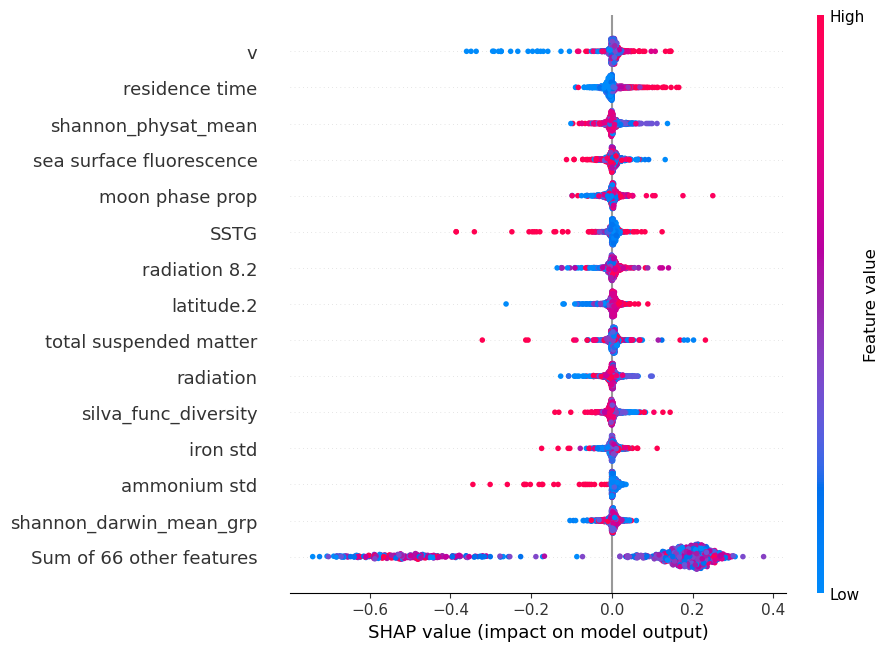

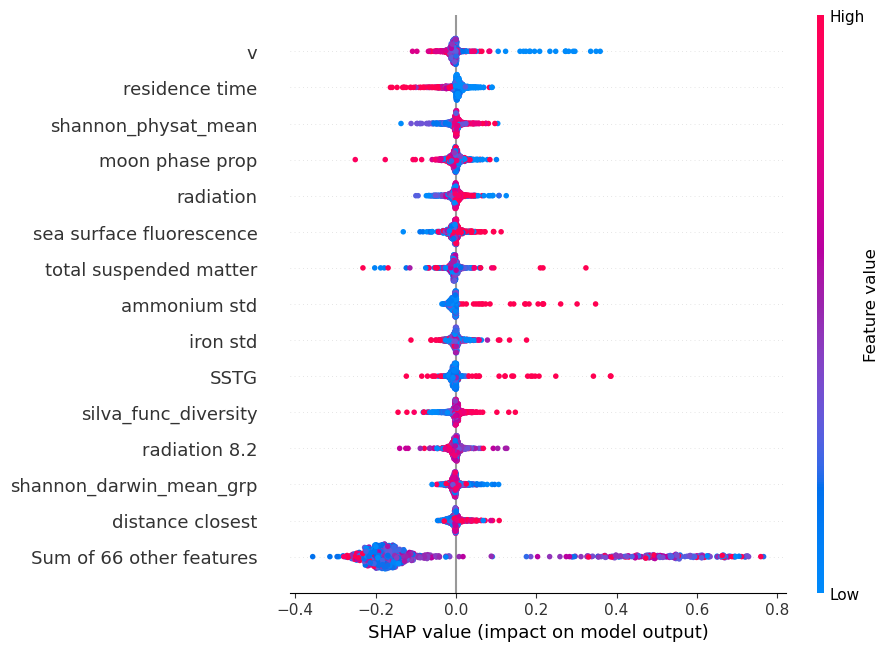

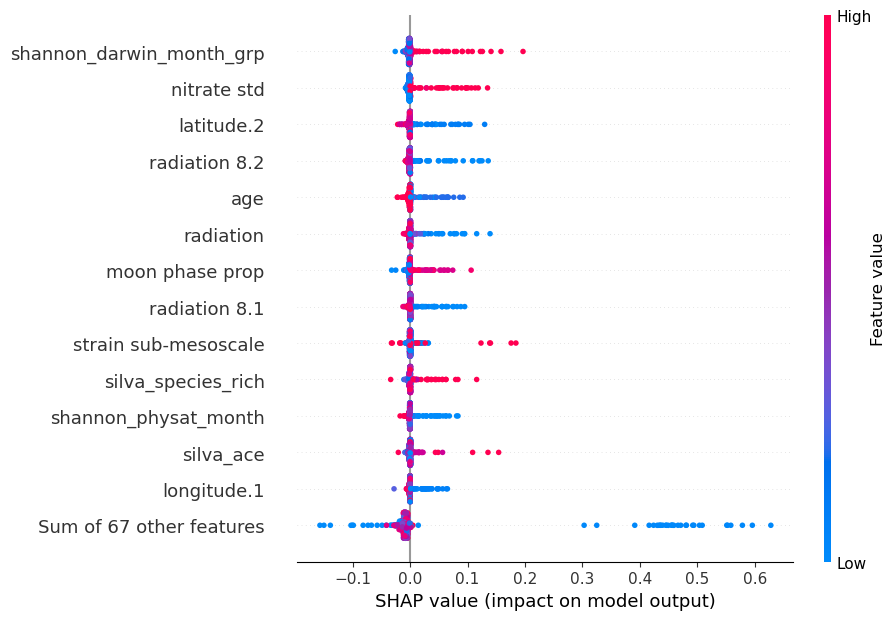

In [69]:
shap.plots.beeswarm(shap_values[:, :, 0], max_display = 15)  # Klasse 1
shap.plots.beeswarm(shap_values[:, :, 1], max_display = 15)  # Klasse 2
shap.plots.beeswarm(shap_values[:, :, 2], max_display = 14)  # Klasse 3

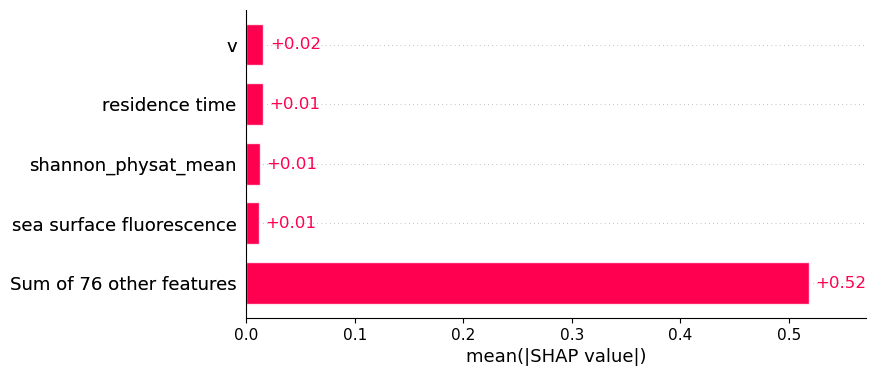

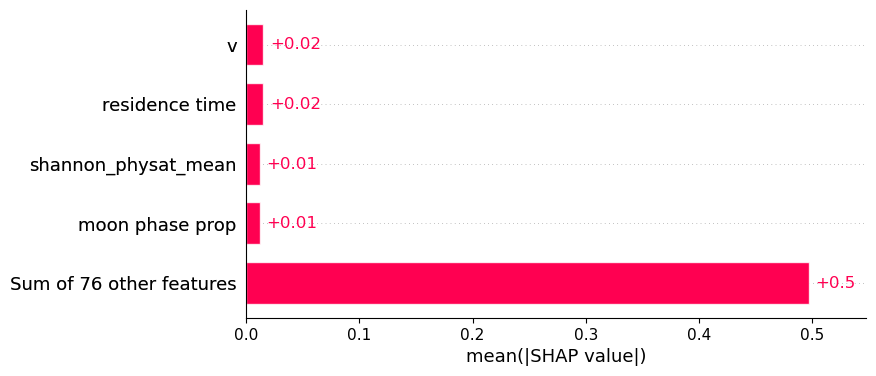

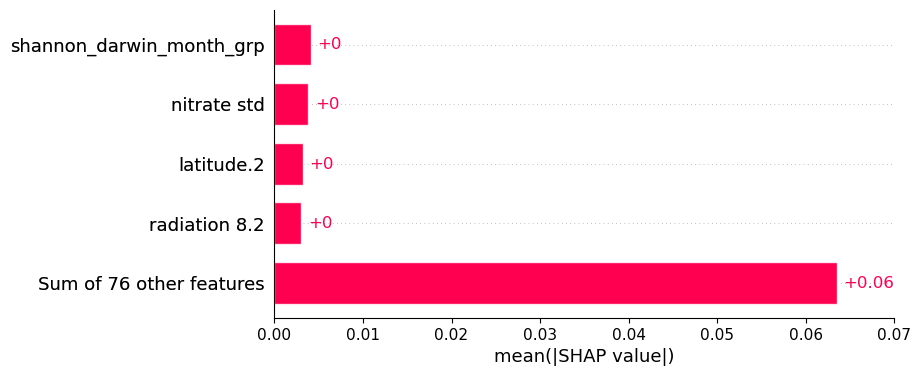

In [73]:
# Plot for a specific class (most commonly class 1)
shap.plots.bar(shap_values[..., 0], max_display = 5)  # Replace 1 with your target class
# Plot for a specific class (most commonly class 1)
shap.plots.bar(shap_values[..., 1], max_display = 5)  # Replace 1 with your target class
# Plot for a specific class (most commonly class 1)
shap.plots.bar(shap_values[..., 2], max_display = 5)  # Replace 1 with your target class

In [147]:
y_bin = label_binarize(y_imp_dif, classes=[1, 2, 3])

X_train_dif, X_test, y_train_dif, y_test = train_test_split(
    X_imp_dif, y_bin, stratify = y_bin, test_size=0.4, random_state=42)

print(X_train_dif.shape, y_train_dif.shape,
X_test.shape, y_test.shape)

KNN_dif = KNeighborsClassifier(n_neighbors = 2, weights = 'distance')
clf = OneVsRestClassifier(Pipeline(
    steps=[("scaler", StandardScaler()), ("knn", KNN_dif)]
))
clf.fit(X_train_dif, y_train_dif)

cross_val_scores = cross_val_score(clf, X_imp_dif, y_imp_dif, cv=5)
print('cross validation scores:', cross_val_scores)
print("%0.4f accuracy with a standard deviation of %0.4f" % (cross_val_scores.mean(), cross_val_scores.std()))

y_pred = clf.predict(X_test)
prob_pred = clf.predict_proba(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

print(classification_report(y_test, y_pred))

(492, 80) (492, 3) (329, 80) (329, 3)
cross validation scores: [0.96969697 0.97560976 0.96341463 0.93902439 0.9695122 ]
0.9635 accuracy with a standard deviation of 0.0128
Accuracy: 96.05%
              precision    recall  f1-score   support

           0       0.97      0.98      0.97       243
           1       0.93      0.89      0.91        74
           2       1.00      1.00      1.00        12

   micro avg       0.96      0.96      0.96       329
   macro avg       0.97      0.96      0.96       329
weighted avg       0.96      0.96      0.96       329
 samples avg       0.96      0.96      0.96       329



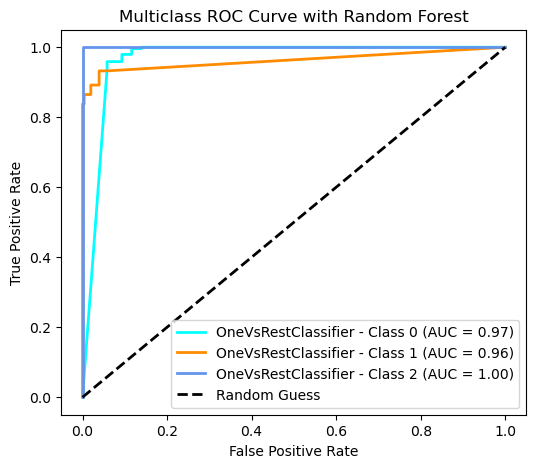

In [148]:
fpr = dict()
tpr = dict()
roc_auc = dict()

model = [clf]

plt.figure(figsize=(6, 5))
colors = cycle(['aqua', 'darkorange', 'cornflowerblue'])

for clf in model:
    for i, color in zip(range(clf.classes_.shape[0]), colors):
        fpr[i], tpr[i], _ = roc_curve(
            y_test[:, i], clf.predict_proba(X_test)[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label=f'{clf.__class__.__name__} - Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve with Random Forest')
plt.legend(loc="lower right")
plt.show()

In [119]:
def numeric_columns(df):
    numeric_cols = []
    for col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]):
            numeric_cols.append(col)
    return numeric_cols
# Load dataset
df = pd.read_csv("15 features - no imp.csv")

# Use function to extract numeric columns
numeric_cols = numeric_columns(df)

# Create a copy of the DataFrame
df_numeric = df[numeric_cols].copy()

# Now you can safely modify df_numeric
df_numeric['mhw_category'] = df['mhw_category']

replace_category = {
    'none': 0,
    'Moderate': 1,
    'Strong': 2,
    'Severe': 3
}

df_numeric['mhw_category'] = df['mhw_category'].replace(replace_category)

print(df_numeric['mhw_category'].value_counts())

# Shuffle the DataFrame
shuffled_df_numeric = shuffle(df_numeric, random_state=42)

# Separate features (X) and labels (y) after shuffling
X = shuffled_df_numeric.drop(['mhw_category'], axis=1)
y = shuffled_df_numeric['mhw_category']
X.shape, y.shape

mhw_category
1    605
2    185
3     31
Name: count, dtype: int64


C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_22988\2513506105.py:26: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_numeric['mhw_category'] = df['mhw_category'].replace(replace_category)


((821, 15), (821,))

In [120]:
nan = np.nan
imputer = KNNImputer(n_neighbors = 7, weights = 'distance')
imputed = imputer.fit_transform(shuffled_df_numeric)
imputed_df_dif = pd.DataFrame(imputed, columns = shuffled_df_numeric.columns)
imputed_df_dif.shape
# Shuffle the DataFrame
shuffled_imp_dif = shuffle(imputed_df_dif, random_state=42)
shuffled_imp_dif = shuffled_imp_dif.rename({'sea surface temp': 'SST', 'sea surface chlorophyll a': 'SSCa', 'sea surface temp grad': 'SSTG'}, axis = 1)

# Separate features (X) and labels (y) after shuffling
X_imp_dif = shuffled_imp_dif.drop(['mhw_category'], axis=1)
y_imp_dif = shuffled_imp_dif['mhw_category']
print(X_imp_dif)

     ammonium  ammonium std   nitrite  nitrite std   nitrate  nitrate std  \
609  0.020278      0.001160  0.004047     0.000429  0.004699     0.004168   
174  0.020278      0.001160  0.004047     0.000429  0.004699     0.004168   
67   0.012845      0.000930  0.029691     0.004530  0.012457     0.004551   
168  0.012845      0.000930  0.029691     0.004530  0.012457     0.004551   
275  0.011802      0.001069  0.003029     0.000641  0.016039     0.007218   
..        ...           ...       ...          ...       ...          ...   
71   0.025510      0.004298  0.004729     0.001665  0.003324     0.002387   
106  0.027012      0.012327  0.039164     0.031951  0.218452     0.409661   
270  0.001088      0.000728  0.006602     0.006331  6.861202     2.833806   
435  0.017368      0.001913  0.026568     0.005028  0.009585     0.006024   
102  0.012245      0.000652  0.002289     0.000248  0.014058     0.004599   

         iron      iron std  okubo-weiss      SSCa  radiation 8.1  \
609  0

In [150]:
y_bin = label_binarize(y_imp_dif, classes=[1, 2, 3])

X_train_dif, X_test, y_train_dif, y_test = train_test_split(
    X_imp_dif, y_bin, stratify = y_bin, test_size=0.3, random_state=42)

print(X_train_dif.shape, y_train_dif.shape,
X_test.shape, y_test.shape)

KNN_dif = KNeighborsClassifier(n_neighbors = 3, weights = 'distance')
clf_1 = OneVsRestClassifier(Pipeline(
    steps=[("scaler", StandardScaler()), ("knn", KNN_dif)]
))
clf_1.fit(X_train_dif, y_train_dif)

cross_val_scores = cross_val_score(clf_1, X_imp_dif, y_imp_dif, cv=5)
print('cross validation scores:', cross_val_scores)
print("%0.4f accuracy with a standard deviation of %0.4f" % (cross_val_scores.mean(), cross_val_scores.std()))

y_pred = clf_1.predict(X_test)
prob_pred = clf_1.predict_proba(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

print(classification_report(y_test, y_pred))

print(type(y_test))
print(y_test.shape)

(574, 80) (574, 3) (247, 80) (247, 3)
cross validation scores: [0.96363636 0.9695122  0.95731707 0.93292683 0.9695122 ]
0.9586 accuracy with a standard deviation of 0.0136
Accuracy: 96.36%
              precision    recall  f1-score   support

           0       0.95      1.00      0.98       182
           1       1.00      0.84      0.91        56
           2       1.00      1.00      1.00         9

   micro avg       0.96      0.96      0.96       247
   macro avg       0.98      0.95      0.96       247
weighted avg       0.97      0.96      0.96       247
 samples avg       0.96      0.96      0.96       247

<class 'numpy.ndarray'>
(247, 3)


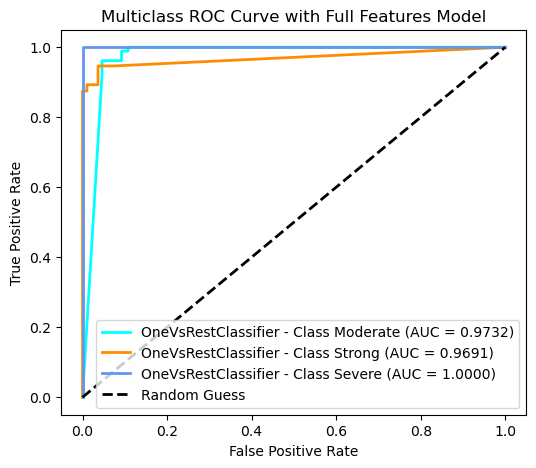

In [153]:
fpr = dict()
tpr = dict()
roc_auc = dict()

model = [clf_1]

plt.figure(figsize=(6, 5))
colors = cycle(['aqua', 'darkorange', 'cornflowerblue'])

Classes = ['Moderate', 'Strong', 'Severe']

for clf in model:
    for i, color in zip(range(clf.classes_.shape[0]), colors):
        fpr[i], tpr[i], _ = roc_curve(
            y_test[:, i], clf.predict_proba(X_test)[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label=f'{clf.__class__.__name__} - Class {Classes[i]} (AUC = {roc_auc[i]:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve with Full Features Model')
plt.legend(loc="lower right")
plt.show()

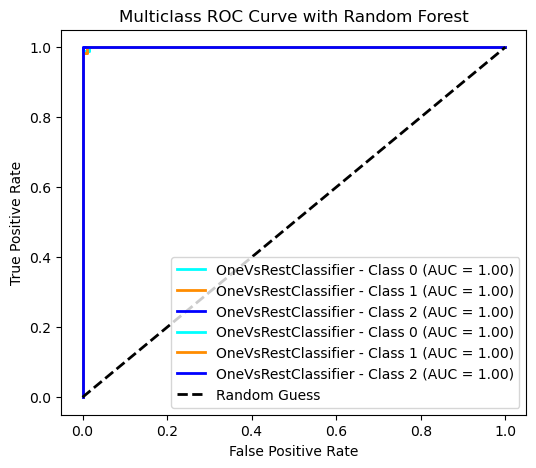

In [128]:
fpr = dict()
tpr = dict()
roc_auc = dict()

model = [clf, clf_1]

plt.figure(figsize=(6, 5))
colors = cycle(['aqua', 'darkorange', 'blue'])

for clf in model:
    for i, color in zip(range(clf.classes_.shape[0]), colors):
        fpr[i], tpr[i], _ = roc_curve(
            y_test[:, i], clf.predict_proba(X_test)[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label=f'{clf.__class__.__name__} - Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve with Random Forest')
plt.legend(loc="lower right")
plt.show()

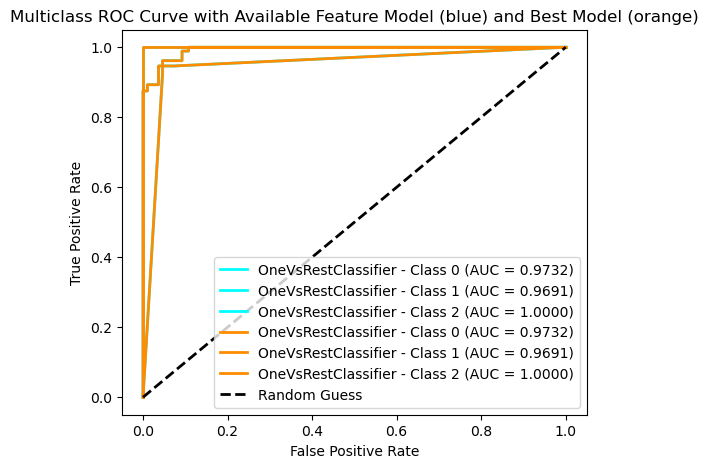

In [159]:
fpr = dict()
tpr = dict()
roc_auc = dict()

models = [clf_1, clf]

plt.figure(figsize=(6, 5))
colors = cycle(['aqua', 'darkorange'])

for model, color in zip(models, colors):
    for i in range(model.classes_.shape[0]):
        fpr[i], tpr[i], _ = roc_curve(
            y_test[:, i], model.predict_proba(X_test)[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label=f'{model.__class__.__name__} - Class {i} (AUC = {roc_auc[i]:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve with Available Feature Model (blue) and Best Model (orange)')
plt.legend(loc="lower right")
plt.show()

In [157]:
from sklearn.metrics import roc_auc_score

micro_roc_auc_ovr = roc_auc_score(
    y_test,
    y_pred,
    multi_class="ovr",
    average="micro",
)

print(f"Micro-averaged One-vs-Rest ROC AUC score:\n{micro_roc_auc_ovr:.4f}")

Micro-averaged One-vs-Rest ROC AUC score:
0.9727
